# Ridge Regression

Ridge Regression is a regularized version of Linear Regression that prevents overfitting by adding a penalty term to the loss function.

## Import libraries and dataset


In [7]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [18]:
#Importing the dataset
df = pd.read_csv('/content/HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Define variables and split into train and test set


In [9]:
df.dropna(inplace=True)

In [10]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [11]:
# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

## Apply Ridge Regression

In [12]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(x_train, y_train)

Ridge(alpha=10)

In [13]:
print(f"Aplha = {ridge_model.alpha}")
print(pd.Series(ridge_model.coef_, index=X.columns))

Aplha = 10
CRIM      -0.107317
ZN         0.051403
INDUS     -0.030647
CHAS       0.767404
NOX       -1.307447
RM         3.877520
AGE       -0.029940
DIS       -1.199391
RAD        0.232671
TAX       -0.017002
PTRATIO   -0.738776
B          0.009415
LSTAT     -0.412900
dtype: float64


Plot coefficients vs column names

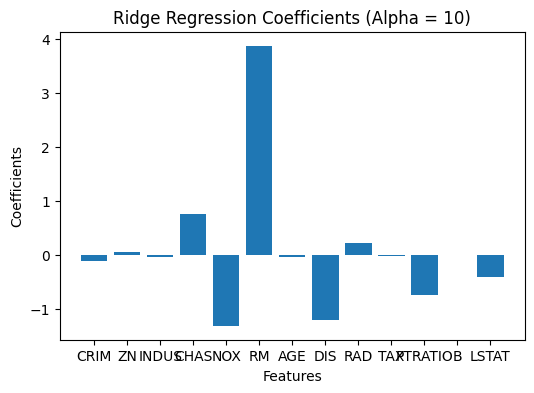

In [14]:
coefficients = ridge_model.coef_ #Store coefficients

plt.figure(figsize=(6,4))
plt.bar(X.columns, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.title(f"Ridge Regression Coefficients (Alpha = {ridge_model.alpha})")
plt.show()

Alpha = 0.0100 | Coefficients = [-1.12908735e-01  4.50050539e-02  5.64309550e-02  1.17964599e+00
 -1.70429972e+01  4.27276541e+00 -2.01690621e-02 -1.40352331e+00
  2.76898251e-01 -1.68158740e-02 -8.94340643e-01  9.08141590e-03
 -3.64802112e-01]
Alpha = 0.0126 | Coefficients = [-1.12887295e-01  4.50169665e-02  5.61404548e-02  1.17929223e+00
 -1.69884322e+01  4.27312333e+00 -2.02137226e-02 -1.40279086e+00
  2.76696609e-01 -1.68149918e-02 -8.93741815e-01  9.08378799e-03
 -3.64854847e-01]
Alpha = 0.0160 | Coefficients = [-1.12860375e-01  4.50319348e-02  5.57756616e-02  1.17884671e+00
 -1.69199142e+01  4.27357130e+00 -2.02697944e-02 -1.40187116e+00
  2.76443451e-01 -1.68138855e-02 -8.92989914e-01  9.08676570e-03
 -3.64921166e-01]
Alpha = 0.0202 | Coefficients = [-1.12826639e-01  4.50507102e-02  5.53184346e-02  1.17828626e+00
 -1.68340372e+01  4.27413039e+00 -2.03400579e-02 -1.40071851e+00
  2.76126229e-01 -1.68125014e-02 -8.92047604e-01  9.09049627e-03
 -3.65004444e-01]
Alpha = 0.0256 | Coe

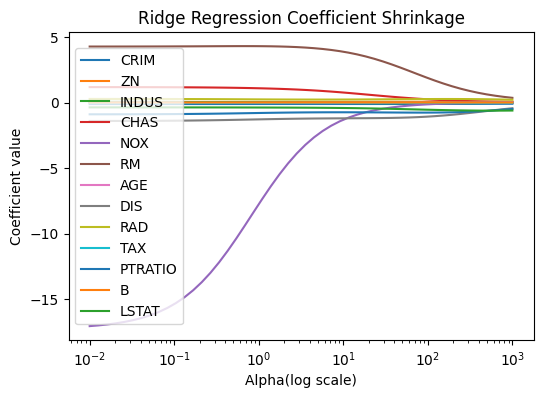

In [15]:
#Generate alpha values on log scale
alphas = np.logspace(-2, 3, 50)

#Store coefficients
coefficients_path = []

for alpha_value in alphas:
  ridge_model = Ridge(alpha=alpha_value)
  ridge_model.fit(x_train, y_train)
  coefficients_path.append(ridge_model.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {ridge_model.coef_}") #Printing coefficients

coefficients_path = np.array(coefficients_path) #Convert to numpy array

#plot
plt.figure(figsize=(6,4))
plt.plot(alphas, coefficients_path)
plt.xscale('log')
plt.xlabel('Alpha(log scale)')
plt.ylabel('Coefficient value')
plt.title('Ridge Regression Coefficient Shrinkage')
plt.legend(X.columns)

In [16]:
from sklearn.linear_model import LinearRegression # Added import for LinearRegression

# Apply Linear Regression
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# Calculate R2 scores for Linear Regression
r2_train_linear = linear_model.score(x_train, y_train)
r2_val_linear = linear_model.score(x_val, y_val)
r2_test_linear = linear_model.score(x_test, y_test)


In [17]:
ridge_model_alpha_10 = Ridge(alpha=10)
ridge_model_alpha_10.fit(x_train, y_train)

# Calculate R2 scores for Ridge Regression (with alpha=10 for consistency, or whatever alpha was used for the initial model)
r2_train_ridge = ridge_model_alpha_10.score(x_train, y_train)
r2_val_ridge = ridge_model_alpha_10.score(x_val, y_val)
r2_test_ridge = ridge_model_alpha_10.score(x_test, y_test)

print("--- Linear Regression R2 Scores ---")
print(f"R2 Score (Train): {r2_train_linear:.4f}")
print(f"R2 Score (Validation): {r2_val_linear:.4f}")
print(f"R2 Score (Test): {r2_test_linear:.4f}")
print(f"\n--- Ridge Regression R2 Scores (Alpha = {ridge_model_alpha_10.alpha}) ---")
print(f"R2 Score (Train): {r2_train_ridge:.4f}")
print(f"R2 Score (Validation): {r2_val_ridge:.4f}")
print(f"R2 Score (Test): {r2_test_ridge:.4f}")

--- Linear Regression R2 Scores ---
R2 Score (Train): 0.7939
R2 Score (Validation): 0.5837
R2 Score (Test): 0.7191

--- Ridge Regression R2 Scores (Alpha = 10) ---
R2 Score (Train): 0.7832
R2 Score (Validation): 0.5674
R2 Score (Test): 0.7064
